<a href="https://colab.research.google.com/github/Sravanalakshmi09/Internship/blob/main/Day%209/Accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression for SignalSense — IoT Sensor Anomaly Detection Dashboard

This section will demonstrate how to build a logistic regression model to classify spam messages using the 'synthetic_iot_dataset.csv' dataset.

First 5 Rows
  Device_ID  Temperature   Humidity  Battery_Level  Anomaly
0  Device_1    32.483571  43.248217             43        0
1  Device_2    29.308678  48.554813             70        0
2  Device_3    33.238443  42.075801             29        0
3  Device_4    37.615149  46.920385             91        0
4  Device_5    28.829233  31.063853             40        0

Dataset Shape: (2000, 5)

Missing Values
Device_ID        0
Temperature      0
Humidity         0
Battery_Level    0
Anomaly          0
dtype: int64

Features:
Index(['Temperature', 'Humidity', 'Battery_Level'], dtype='object')

Best Hyperparameters
{'C': np.float64(3.7554011884736247), 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation Accuracy
1.0

Test Accuracy
99.75%

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       361
           1       1.00      0.97      0.99        39

    accuracy                           1.00       400
   

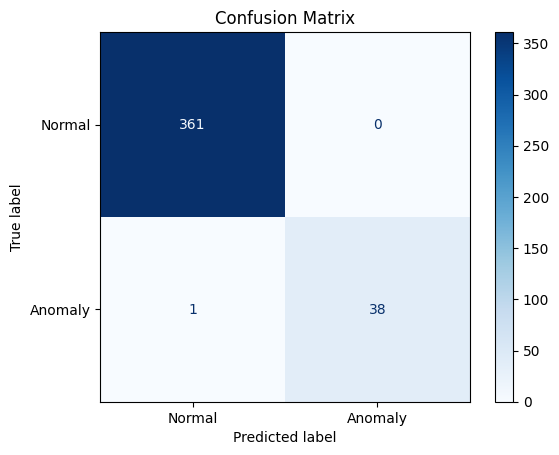


Feature Importance
         Feature  Coefficient  Absolute
0    Temperature     4.550294  4.550294
2  Battery_Level    -2.576388  2.576388
1       Humidity     0.056904  0.056904


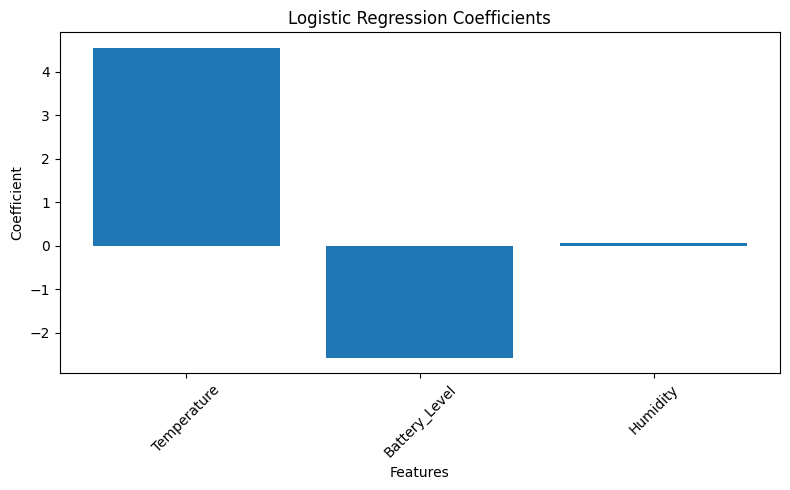


New Sensor Prediction
Probability (Normal): 0.9999
Probability (Anomaly): 0.0001
✅ Normal Sensor

Model Saved Successfully!
signalsense_logistic_randomsearch_model.pkl
signalsense_scaler.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# SignalSense - IoT Sensor Anomaly Detection
# Logistic Regression with RandomizedSearchCV
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy.stats import uniform
import joblib

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("/content/drive/MyDrive/synthetic_iot_dataset.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

# ============================================================
# Prepare Features and Target
# ============================================================

X = df.drop(columns=["Device_ID", "Anomaly"])
y = df["Anomaly"]

print("\nFeatures:")
print(X.columns)

# ============================================================
# Split Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# Logistic Regression Model
# ============================================================

log_model = LogisticRegression(max_iter=1000)

# ============================================================
# Hyperparameter Search Space
# ============================================================

param_dist = {
    "C": uniform(0.01, 10),
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear", "newton-cg", "saga"]
}

# ============================================================
# Randomized Search CV
# ============================================================

random_search = RandomizedSearchCV(
    estimator=log_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# ============================================================
# Best Parameters
# ============================================================

print("\n===================================")
print("Best Hyperparameters")
print("===================================")

print(random_search.best_params_)

print("\nBest Cross Validation Accuracy")
print(random_search.best_score_)

# ============================================================
# Best Model
# ============================================================

best_model = random_search.best_estimator_

# ============================================================
# Predictions
# ============================================================

y_pred = best_model.predict(X_test)

# ============================================================
# Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("Test Accuracy")
print("===================================")

print(f"{accuracy*100:.2f}%")

# ============================================================
# Classification Report
# ============================================================

print("\n===================================")
print("Classification Report")
print("===================================")

print(classification_report(y_test, y_pred))

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ============================================================
# Feature Importance (Coefficients)
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

print("\n===================================")
print("Feature Importance")
print("===================================")

print(importance)

# Plot Feature Importance
plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Coefficient"])
plt.xticks(rotation=45)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()

# ============================================================
# Predict New Sensor Reading
# ============================================================

# Format:
# [Temperature, Humidity, Battery_Level]

new_sensor = [[35.2, 48.0, 65]]

new_sensor_scaled = scaler.transform(new_sensor)

prediction = best_model.predict(new_sensor_scaled)[0]
probability = best_model.predict_proba(new_sensor_scaled)[0]

print("\n===================================")
print("New Sensor Prediction")
print("===================================")

print(f"Probability (Normal): {probability[0]:.4f}")
print(f"Probability (Anomaly): {probability[1]:.4f}")

if prediction == 1:
    print("🚨 Anomaly Detected")
else:
    print("✅ Normal Sensor")

# ============================================================
# Save Model
# ============================================================

joblib.dump(best_model, "signalsense_logistic_randomsearch_model.pkl")
joblib.dump(scaler, "signalsense_scaler.pkl")

print("\nModel Saved Successfully!")
print("signalsense_logistic_randomsearch_model.pkl")
print("signalsense_scaler.pkl")

## Decision Tree Classifier with RandomizedSearchCV

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# ============================================================
# Decision Tree Classifier Model
# ============================================================

dt_model = DecisionTreeClassifier(random_state=42)

# ============================================================
# Hyperparameter Search Space for Decision Tree
# ============================================================

dt_param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# ============================================================
# Randomized Search CV for Decision Tree
# ============================================================

dt_random_search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=dt_param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

dt_random_search.fit(X_train, y_train)

# ============================================================
# Best Parameters for Decision Tree
# ============================================================

print("\n===================================")
print("Best Hyperparameters for Decision Tree")
print("===================================")

print(dt_random_search.best_params_)

print("\nBest Cross Validation Accuracy for Decision Tree")
print(dt_random_search.best_score_)



Best Hyperparameters for Decision Tree
{'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20, 'criterion': 'gini'}

Best Cross Validation Accuracy for Decision Tree
1.0



Test Accuracy for Decision Tree
100.00%

Classification Report for Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       361
           1       1.00      1.00      1.00        39

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



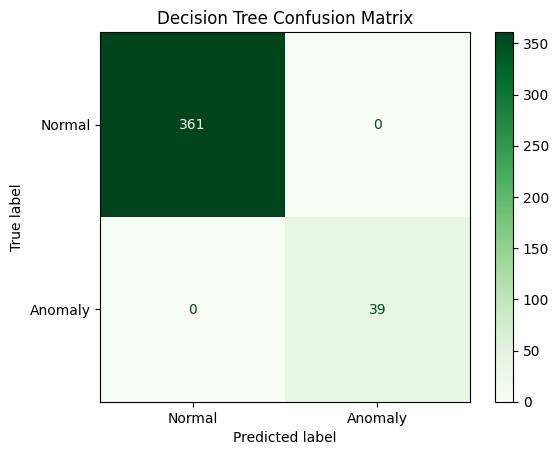

In [ ]:
# ============================================================
# Best Decision Tree Model
# ============================================================

best_dt_model = dt_random_search.best_estimator_

# ============================================================
# Predictions with Decision Tree
# ============================================================

dt_y_pred = best_dt_model.predict(X_test)

# ============================================================
# Accuracy for Decision Tree
# ============================================================

dt_accuracy = accuracy_score(y_test, dt_y_pred)

print("\n===================================")
print("Test Accuracy for Decision Tree")
print("===================================")

print(f"{dt_accuracy*100:.2f}%")

# ============================================================
# Classification Report for Decision Tree
# ============================================================

print("\n===================================")
print("Classification Report for Decision Tree")
print("===================================")

print(classification_report(y_test, dt_y_pred))

# ============================================================
# Confusion Matrix for Decision Tree
# ============================================================

dt_cm = confusion_matrix(y_test, dt_y_pred)

dt_disp = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["Normal", "Anomaly"]
)

dt_disp.plot(cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.show()



Decision Tree Feature Importance
         Feature  Importance
2  Battery_Level         1.0
0    Temperature         0.0
1       Humidity         0.0


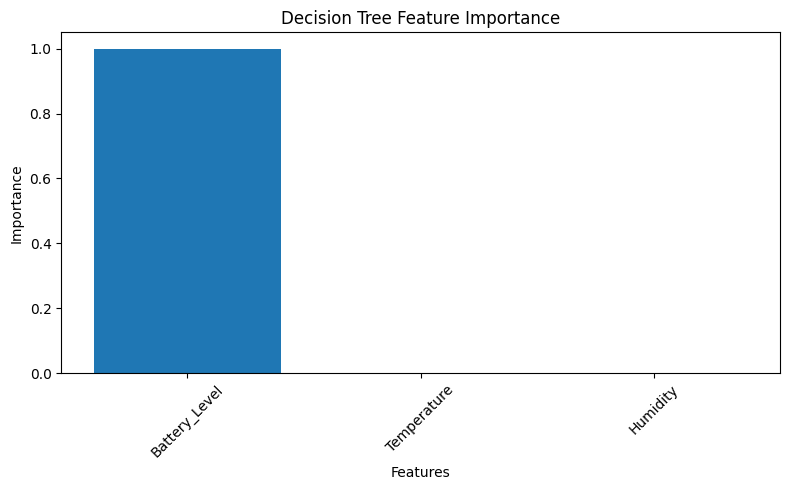

In [ ]:
# ============================================================
# Feature Importance (Decision Tree)
# ============================================================

dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dt_model.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n===================================")
print("Decision Tree Feature Importance")
print("===================================")

print(dt_importance)

# Plot Feature Importance
plt.figure(figsize=(8,5))
plt.bar(dt_importance["Feature"], dt_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Decision Tree Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Predict New Sensor Reading with Decision Tree
# ============================================================

# Use the same 'new_sensor' and 'scaler' from previous section
# new_sensor = [[35.2, 48.0, 65]]
# new_sensor_scaled = scaler.transform(new_sensor)

dt_prediction = best_dt_model.predict(new_sensor_scaled)[0]
dt_probability = best_dt_model.predict_proba(new_sensor_scaled)[0]

print("\n===================================")
print("New Sensor Prediction (Decision Tree)")
print("===================================")

print(f"Probability (Normal): {dt_probability[0]:.4f}")
print(f"Probability (Anomaly): {dt_probability[1]:.4f}")

if dt_prediction == 1:
    print("🚨 Anomaly Detected")
else:
    print("✅ Normal Sensor")

# ============================================================
# Save Decision Tree Model
# ============================================================

joblib.dump(best_dt_model, "signalsense_decision_tree_randomsearch_model.pkl")
# The scaler is the same, no need to resave unless explicitly requested or if different preprocessing is done
# joblib.dump(scaler, "signalsense_scaler.pkl")

print("\nDecision Tree Model Saved Successfully!")
print("signalsense_decision_tree_randomsearch_model.pkl")



New Sensor Prediction (Decision Tree)
Probability (Normal): 1.0000
Probability (Anomaly): 0.0000
✅ Normal Sensor

Decision Tree Model Saved Successfully!
signalsense_decision_tree_randomsearch_model.pkl


### Comparison of Confusion Matrices
We can now compare the Logistic Regression results with the Decision Tree results side-by-side.

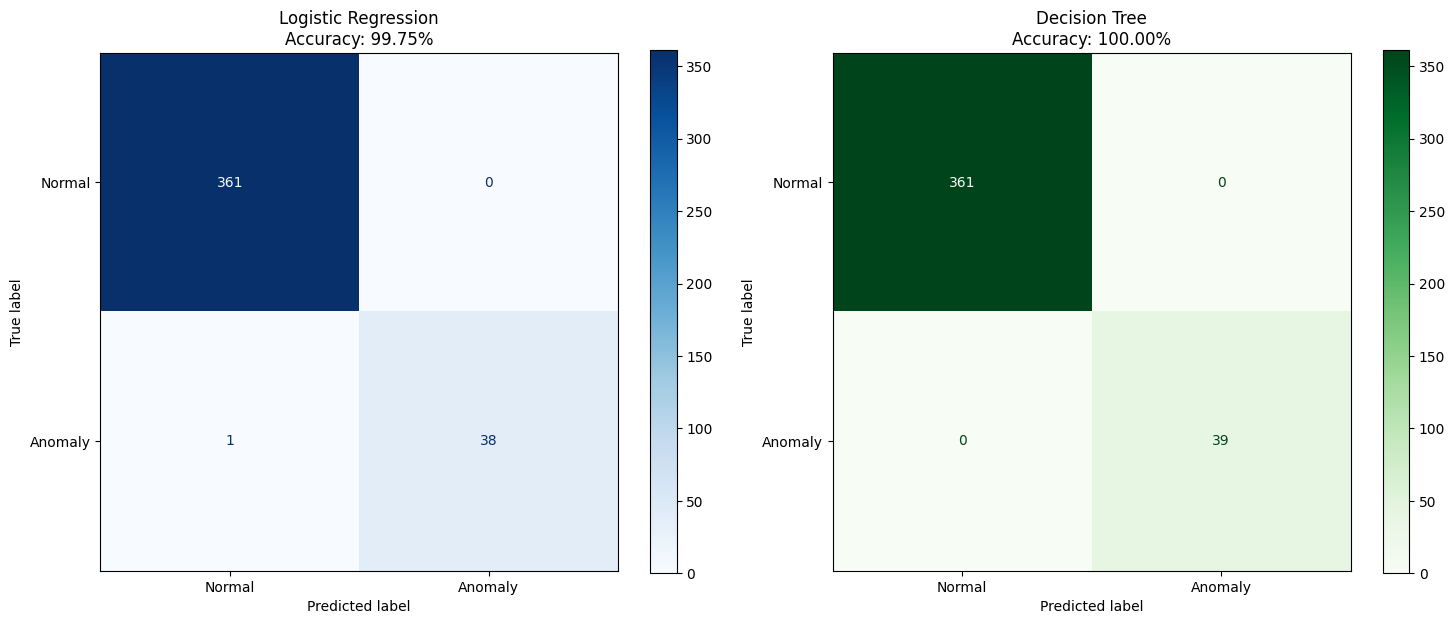

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Logistic Regression Confusion Matrix
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp_log.plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Logistic Regression\nAccuracy: {accuracy*100:.2f}%')

# Plot Decision Tree Confusion Matrix
disp_dt = ConfusionMatrixDisplay(confusion_matrix=dt_cm, display_labels=['Normal', 'Anomaly'])
disp_dt.plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f'Decision Tree\nAccuracy: {dt_accuracy*100:.2f}%')

plt.tight_layout()
plt.show()

## Random Forest Classifier with RandomizedSearchCV

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Random Forest Classifier Model
# ============================================================

rf_model = RandomForestClassifier(random_state=42)

# ============================================================
# Hyperparameter Search Space for Random Forest
# ============================================================

rf_param_dist = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

# ============================================================
# Randomized Search CV for Random Forest
# ============================================================

rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

# ============================================================
# Best Parameters
# ============================================================

print("\n===================================")
print("Best Hyperparameters for Random Forest")
print("===================================")
print(rf_random_search.best_params_)

best_rf_model = rf_random_search.best_estimator_


Best Hyperparameters for Random Forest
{'n_estimators': 50, 'min_samples_split': 5, 'max_depth': None, 'criterion': 'entropy', 'bootstrap': True}



Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       361
           1       1.00      1.00      1.00        39

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



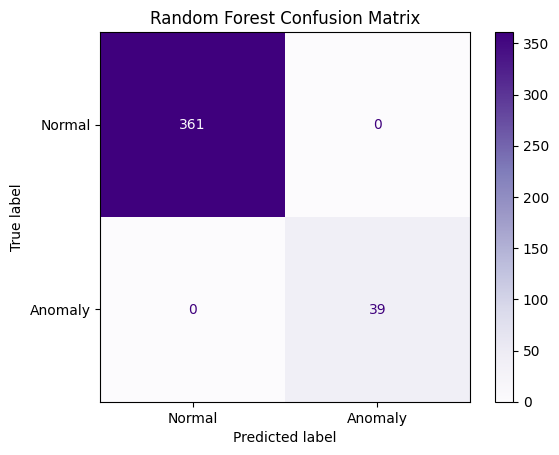

In [ ]:
# ============================================================
# Evaluation
# ============================================================

rf_y_pred = best_rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_y_pred)

print(f"\nTest Accuracy: {rf_accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred))

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_y_pred)
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['Normal', 'Anomaly'])
rf_disp.plot(cmap='Purples')
plt.title("Random Forest Confusion Matrix")
plt.show()

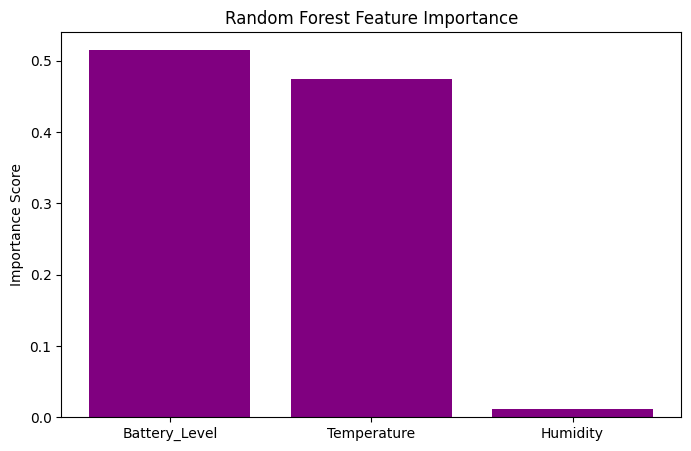

Random Forest model saved as signalsense_rf_model.pkl


In [ ]:
# ============================================================
# Feature Importance (Random Forest)
# ============================================================

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(rf_importance["Feature"], rf_importance["Importance"], color='purple')
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance Score")
plt.show()

# Save Model
joblib.dump(best_rf_model, "signalsense_rf_model.pkl")
print("Random Forest model saved as signalsense_rf_model.pkl")

### Comparison: Logistic Regression vs. Random Forest
Let's compare the confusion matrices of the first model (Logistic Regression) and our latest model (Random Forest).

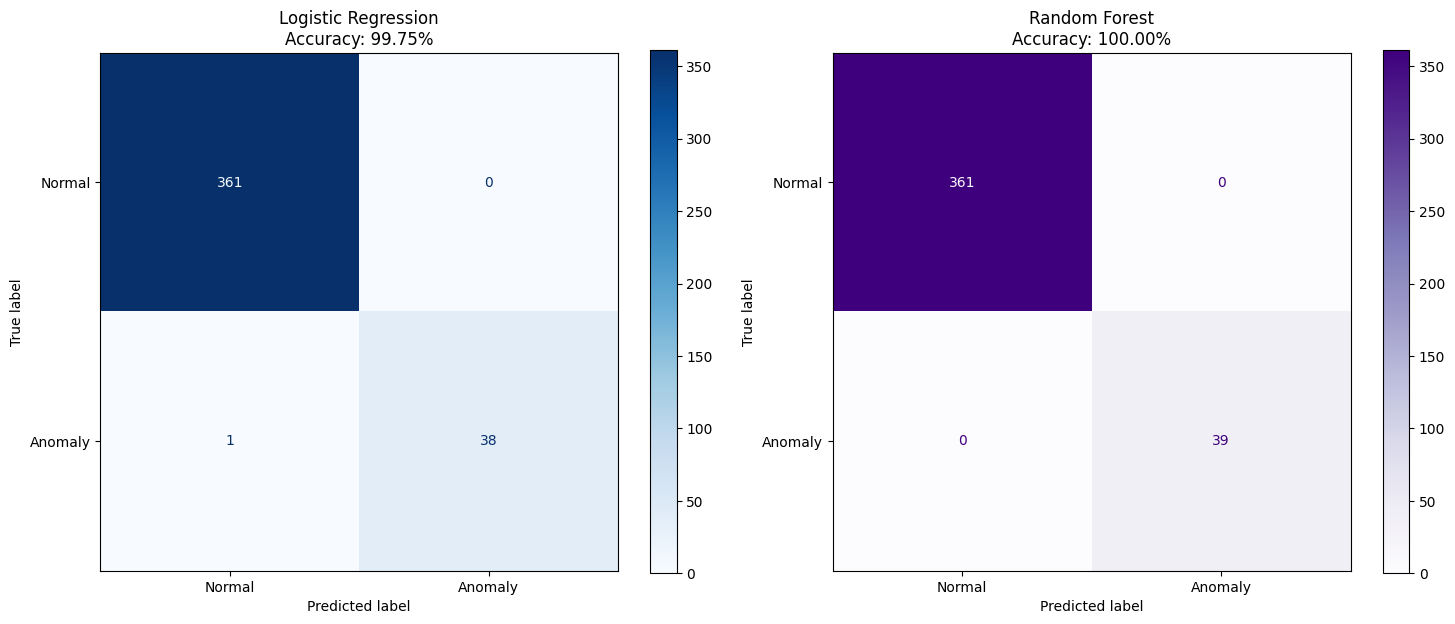

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Logistic Regression Confusion Matrix
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp_log.plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Logistic Regression\nAccuracy: {accuracy*100:.2f}%')

# Plot Random Forest Confusion Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['Normal', 'Anomaly'])
disp_rf.plot(ax=axes[1], cmap='Purples')
axes[1].set_title(f'Random Forest\nAccuracy: {rf_accuracy*100:.2f}%')

plt.tight_layout()
plt.show()

### Comprehensive Comparison: All 3 Models
Finally, let's look at all three confusion matrices together to conclude our model evaluation.

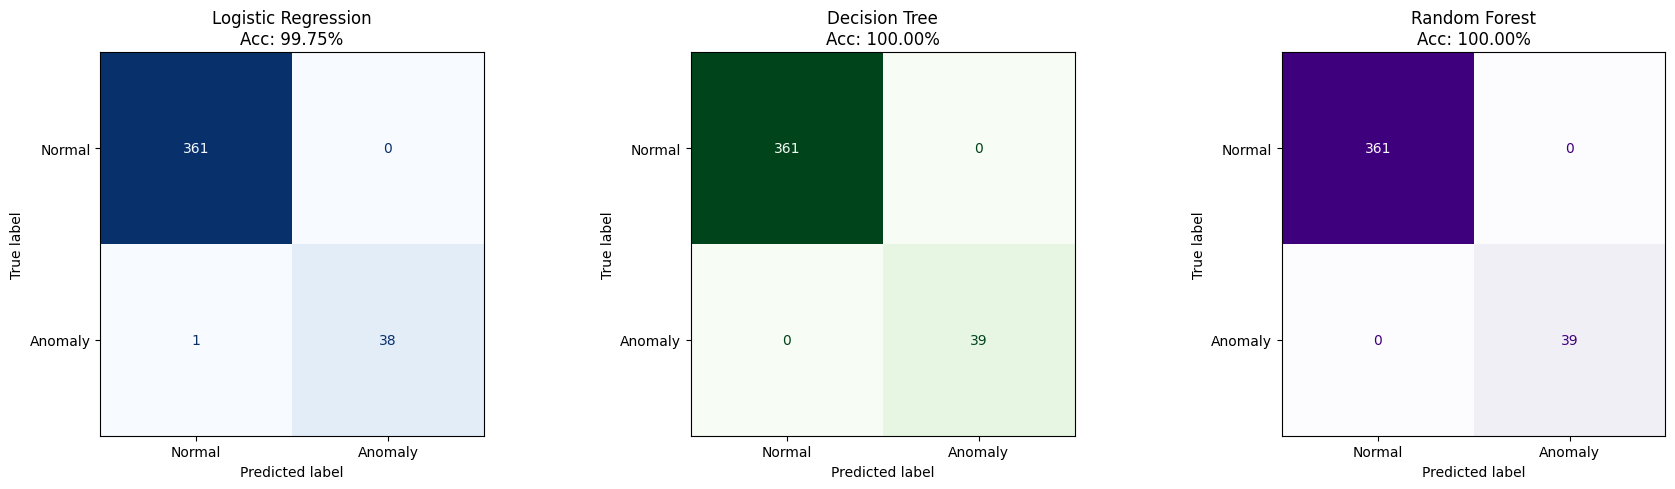

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp_log.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Logistic Regression\nAcc: {accuracy*100:.2f}%')

# Decision Tree
disp_dt = ConfusionMatrixDisplay(confusion_matrix=dt_cm, display_labels=['Normal', 'Anomaly'])
disp_dt.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'Decision Tree\nAcc: {dt_accuracy*100:.2f}%')

# Random Forest
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['Normal', 'Anomaly'])
disp_rf.plot(ax=axes[2], cmap='Purples', colorbar=False)
axes[2].set_title(f'Random Forest\nAcc: {rf_accuracy*100:.2f}%')

plt.tight_layout()
plt.show()